In [2]:
import numpy as np
import pandas as pd
import time
from tqdm import tqdm
import itertools

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

from MyRandomForest import MyRandomForest

In [3]:
### A function to benchmark a implementation of rf:
def benchmark_rf(clf, X, y, n_tests=5, test_size=0.3):

    accuracies = []
    f1_scores = []
    train_times = []
    test_times = []
    for i in range(n_tests):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)
        model = clf
        
        ### Training
        start = time.time()
        model.fit(X_train, y_train)
        train_times.append(time.time() - start)
        
        ### Testing
        start = time.time()
        y_pred = model.predict(X_test)
        test_times.append(time.time() - start)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
        f1_scores.append(f1)
        
    
    return pd.DataFrame({
        'implementation': [clf.__class__.__name__]*n_tests,
        'n_features': [X.shape[1]]*n_tests,
        'n_samples': [X.shape[0]]*n_tests,
        'seed': list(range(n_tests)),
        'accuracy': accuracies,
        'f1': f1_scores,
        'train_time': train_times,
        'test_time': test_times})

In [4]:
final = None

features_interval = range(100,5001, 100)
samples_interval = range(100, 101, 100)
n_tests = range(10)
n_jobs = 12

tests = [{"features": features_interval, "samples": samples_interval, "n_test":n_test} for features_interval, samples_interval, n_test in list(itertools.product(features_interval, samples_interval, n_tests))]
shuffle = True
if shuffle:
    np.random.shuffle(tests)

for test in tqdm(tests):
    features = test["features"]
    samples = test["samples"]
    n_test = test["n_test"]
    # Create syntetic dataset using scikit
    data = make_classification(n_samples=samples, n_features=features, n_informative=int(features*0.5), n_redundant=int(features*0.25), n_clusters_per_class=2, random_state=n_test,)
    X, y = data
    results = [benchmark_rf(MyRandomForest(n_trees=100, max_depth=7, max_features=None, n_jobs=n_jobs), X, y, n_tests=1),
               benchmark_rf(RandomForestClassifier(n_estimators=100, max_depth=7, max_features=None, n_jobs=n_jobs), X, y, n_tests=1)
            ]

    final = pd.concat([final] + results, ignore_index=True)

 75%|███████▍  | 373/500 [08:56<02:44,  1.30s/it]c:\Users\grkremer\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grkremer\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grkremer\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [5]:
final.to_csv('results/results_v03.csv', index=False)

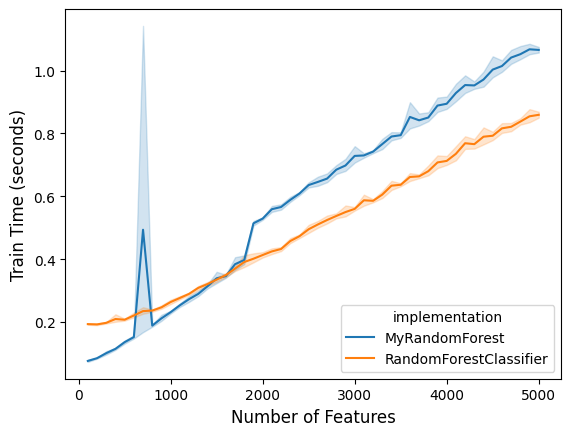

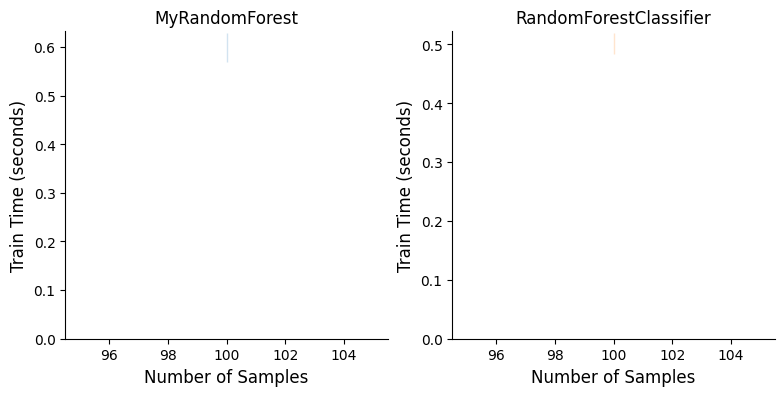

In [6]:
import seaborn as sns

results = pd.concat([pd.read_csv('results/results_v03.csv')], ignore_index=True)

ax = sns.lineplot(data=results, x='n_features', y='train_time', hue='implementation')
# Ensure each facet's y-axis starts at 0

ax.set_ylabel('Train Time (seconds)')
ax.set_xlabel('Number of Features')
ax.title.set_size(12)
ax.xaxis.label.set_size(12)
ax.yaxis.label.set_size(12)
ax.set_title((ax.get_title().replace('implementation = ', '')))

g = sns.FacetGrid(data = results, col='implementation', sharey='col', height=4, hue='implementation')
g.map(sns.lineplot, 'n_samples', "train_time")

# Ensure each facet's y-axis starts at 0
for ax in g.axes.flatten():
    ax.set_ylim(bottom=0)
    ax.set_ylabel('Train Time (seconds)')
    ax.set_xlabel('Number of Samples')
    ax.title.set_size(12)
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.set_title((ax.get_title().replace('implementation = ', '')))